# Построение Soft-Labels | GoEmotions (raw)

Тут использовала `raw`-версию GoEmotions (ответы каждого аннотатора хранятся отдельно).  
Буду брать **долю голосов** за каждую эмоцию и преобразовывать в вектор вещественных чисел.

## Импорты библиотек

In [1]:
import os
import subprocess
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

### Версии библиотек

In [2]:
packages = ["NumPy", "Pandas", "Polars", "Matplotlib", "Seaborn"]
package_objects = [np, pd, pl, mpl, sns]
versions = [obj.__version__ for obj in package_objects]

columns_order = ["№", "Библиотека", "Версия"]
df_pkgs = (
    pl.DataFrame({columns_order[1]: packages, columns_order[2]: versions})
    .with_columns(pl.arange(1, pl.lit(len(packages)) + 1).alias(columns_order[0]))
    .select(columns_order)
)
display(df_pkgs)

№,Библиотека,Версия
i64,str,str
1,"""NumPy""","""2.0.2"""
2,"""Pandas""","""2.2.2"""
3,"""Polars""","""1.35.2"""
4,"""Matplotlib""","""3.10.0"""
5,"""Seaborn""","""0.13.2"""


In [3]:
DATA_DIR = "data"
RAW_DIR = "raw"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RAW_DIR,  exist_ok=True)

EMOTIONS = [
    "admiration", "amusement", "approval", "caring", "desire",
    "excitement", "gratitude", "joy", "love", "optimism",
    "pride", "relief", "anger", "annoyance", "disappointment",
    "disapproval", "disgust", "embarrassment", "fear", "grief",
    "nervousness", "remorse", "sadness", "confusion", "curiosity",
    "realization", "surprise", "neutral",
]
NUM_EMOTIONS = len(EMOTIONS)  # 28

sns.set_theme(style="whitegrid", font_scale=1.05)
print(f"Эмоций: {NUM_EMOTIONS}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"RAW_DIR: {RAW_DIR}")

Эмоций: 28
DATA_DIR: data
RAW_DIR: raw


## Загрузка raw-файлов

Файлы хранятся в официальном репозитории Google Research.

In [4]:
URLS = [
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_3.csv",
]

for url in URLS:
    filename = url.split("/")[-1]
    filepath = os.path.join(RAW_DIR, filename)
    if os.path.exists(filepath) and os.path.getsize(filepath) > 1_000_000:
        size_mb = os.path.getsize(filepath) / 1024 / 1024
        print(f"уже есть: {filename}  ({size_mb:.1f} MB)")
        continue
    subprocess.run(["wget", "-q", "-O", filepath, url])
    size_mb = os.path.getsize(filepath) / 1024 / 1024
    print(f"скачан: {filename} ({size_mb:.1f} MB)")

уже есть: goemotions_1.csv  (13.5 MB)
уже есть: goemotions_2.csv  (13.5 MB)
уже есть: goemotions_3.csv  (13.7 MB)


In [5]:
# Склеиваем три части в один DataFrame
df_full_raw = pd.concat([
    pd.read_csv(os.path.join(RAW_DIR, "goemotions_1.csv"), encoding="utf-8"),
    pd.read_csv(os.path.join(RAW_DIR, "goemotions_2.csv"), encoding="utf-8"),
    pd.read_csv(os.path.join(RAW_DIR, "goemotions_3.csv"), encoding="utf-8"),
], ignore_index=True)

print(f"Всего строк (все аннотаторы) : {len(df_full_raw):>7}")
print(f"Уникальных текстов : {df_full_raw['id'].nunique():>7}")
print(f"Уникальных аннотаторов : {df_full_raw['rater_id'].nunique():>7}")
print(f"example_very_unclear=True : {df_full_raw['example_very_unclear'].sum():>7}")

Всего строк (все аннотаторы) :  211225
Уникальных текстов :   58011
Уникальных аннотаторов :      82
example_very_unclear=True :    3411


## Изучение формата и проверка данных

Смотрим как выглядят строки для одного конкретного текста

In [6]:
# Столбцы и первые строки
print("Столбцы raw-файла:")
print(df_full_raw.columns.tolist())
print()
display(df_full_raw.head(3))

Столбцы raw-файла:
['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']



,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
# Распределение числа аннотаторов на один текст
rater_counts = df_full_raw.groupby("id").size()
print("Распределение числа аннотаторов на один текст:")
print(rater_counts.value_counts().sort_index().to_string())
print(f"\nСреднее аннотаторов на текст: {rater_counts.mean():.2f}")

Распределение числа аннотаторов на один текст:
1       70
2      592
3    37335
4     2104
5    17910

Среднее аннотаторов на текст: 3.64


In [8]:
# Пример текста от всех аннотаторов
example_id = df_full_raw["id"].iloc[0]
example_rows = df_full_raw[df_full_raw["id"] == example_id]

print(f"Текст (id={example_id}):")
print(f"'{example_rows['text'].iloc[0]}'")
print(f"\nОтветы каждого аннотатора:")
for _, row in example_rows.iterrows():
    active = [e for e in EMOTIONS if row[e] == 1]
    unclear = "unclear" if row["example_very_unclear"] else ""
    print(f"rater {row['rater_id']:>4} -> {active if active else ['(нет эмоций)']}{unclear}")

Текст (id=eew5j0j):
'That game hurt.'

Ответы каждого аннотатора:
rater    1 -> ['sadness']
rater   72 -> ['remorse']
rater   52 -> ['sadness']
rater   20 -> ['disappointment']
rater   26 -> ['neutral']


In [9]:
# Примеры, где аннотаторы не совпали (неоднозначные случаи)
print("Примеры с расхождением аннотаторов (неоднозначность):\n")
shown = 0
for text_id, group in df_full_raw.groupby("id"):
    if shown >= 5:
        break
    clean = group[group["example_very_unclear"] == False]
    if len(clean) < 2:
        continue
    votes = clean[EMOTIONS].sum()
    n     = len(clean)
    if ((votes > 0) & (votes < n)).any():
        print(f"id={text_id}: '{clean['text'].iloc[0]}'")
        for _, row in clean.iterrows():
            active = [e for e in EMOTIONS if row[e] == 1]
            print(f"  rater {row['rater_id']:>4} → {active if active else ['(нет эмоций)']}")
        print()
        shown += 1

Примеры с расхождением аннотаторов (неоднозначность):

id=eczb527: 'So much time saved. Not.'
  rater   61 → ['curiosity']
  rater   37 → ['curiosity']
  rater    4 → ['joy']

id=eczb6r7: 'Emotes have a ridiculous amount of effort put into them, which only makes the fact that nobody uses them sadder'
  rater   33 → ['neutral']
  rater   12 → ['sadness']
  rater   36 → ['disapproval']
  rater   72 → ['neutral']
  rater   15 → ['approval', 'realization']

id=eczb770: 'Just life.. I feel like i'm just a parasite that should be removed.'
  rater   55 → ['sadness']
  rater   36 → ['embarrassment', 'sadness']
  rater   16 → ['neutral']
  rater   77 → ['embarrassment']

id=eczbbmd: 'Thanks for the advice man ! Have a great New Year’s Eve'
  rater    2 → ['gratitude']
  rater   81 → ['excitement', 'gratitude']
  rater   51 → ['gratitude']

id=eczbbwt: '*they were not* 😂 perfect. I’m sure they were - that mental image is pretty awesome lol'
  rater    7 → ['amusement', 'realization']
  rater   

## Разбивка на сплиты по id из simplified версии

В raw-файлах нет колонки `split`, поэтому брала `id` из simplified версии


In [10]:
if not os.path.exists(os.path.join(DATA_DIR, "train.csv")):
    print("data/train.csv не найден - загружаем из HuggingFace simplified")
    from datasets import load_dataset

    dataset = load_dataset("go_emotions", "simplified")

    EMOTIONS_HF = [
        "admiration","amusement","anger","annoyance","approval",
        "caring","confusion","curiosity","desire","disappointment",
        "disapproval","disgust","embarrassment","excitement","fear",
        "gratitude","grief","joy","love","nervousness","optimism",
        "pride","realization","relief","remorse","sadness","surprise","neutral"
    ]

    def hf_split_to_df(hf_split):
        records = []
        for item in hf_split:
            row = {"id": item["id"], "text": item["text"]}
            vec = {e: 0 for e in EMOTIONS}
            for idx in item["labels"]:
                emo = EMOTIONS_HF[idx]
                if emo in vec:
                    vec[emo] = 1
            row.update(vec)
            records.append(row)
        return pd.DataFrame(records)

    hf_train = hf_split_to_df(dataset["train"])
    hf_val = hf_split_to_df(dataset["validation"])
    hf_test = hf_split_to_df(dataset["test"])

    hf_train.to_csv(os.path.join(DATA_DIR, "train.csv"), index=False)
    hf_val.to_csv(os.path.join(DATA_DIR, "val.csv"), index=False)
    hf_test.to_csv(os.path.join(DATA_DIR, "test.csv"), index=False)
    print("train.csv / val.csv / test.csv созданы")
else:
    print("data/train.csv найден")

data/train.csv найден


In [11]:
# Загрузка id сплитов и фильтрация raw-данные
train_ids = set(pd.read_csv(os.path.join(DATA_DIR, "train.csv"))["id"])
val_ids = set(pd.read_csv(os.path.join(DATA_DIR, "val.csv"))["id"])
test_ids = set(pd.read_csv(os.path.join(DATA_DIR, "test.csv"))["id"])

train_raw = df_full_raw[df_full_raw["id"].isin(train_ids)].copy()
val_raw = df_full_raw[df_full_raw["id"].isin(val_ids)].copy()
test_raw = df_full_raw[df_full_raw["id"].isin(test_ids)].copy()

# id из raw должны покрывать все id из simplified
all_raw_ids = set(df_full_raw["id"])
missing = (train_ids | val_ids | test_ids) - all_raw_ids
print(f"ID из simplified не найденных в raw: {len(missing)}")
print()
print(f"train_raw : {len(train_raw):>7} строк ({train_raw['id'].nunique()} текстов)")
print(f"val_raw : {len(val_raw):>7} строк ({val_raw['id'].nunique()} текстов)")
print(f"test_raw : {len(test_raw):>7} строк ({test_raw['id'].nunique()} текстов)")

ID из simplified не найденных в raw: 0

train_raw :  155502 строк (43410 текстов)
val_raw :   19440 строк (5426 текстов)
test_raw :   19470 строк (5427 текстов)


## Построение soft-labels

Для каждого уникального текста:
1. Собираем все строки аннотаторов
2. Исключаем строки с `example_very_unclear=True`
3. Для каждой эмоции: `голоса / число_аннотаторов` сопоставляем число от 0.0 до 1.0

In [12]:
def build_soft_labels(raw_df: pd.DataFrame) -> pd.DataFrame:
    records = []

    for text_id, group in raw_df.groupby("id"):
        # Исключаем ненадежные аннотации
        clean = group[group["example_very_unclear"] == False]
        if len(clean) == 0:
            continue

        n_raters = len(clean)
        text = clean["text"].iloc[0]

        # Считаем голоса и нормируем на число аннотаторов
        votes = clean[EMOTIONS].sum()
        soft_vec = (votes / n_raters).round(4)

        row = {"id": text_id, "text": text, "n_raters": n_raters}
        for emo, val in zip(EMOTIONS, soft_vec):
            row[emo] = float(val)

        records.append(row)

    return pd.DataFrame(records)

In [13]:
print("Строим soft-labels для train")
df_train_soft = build_soft_labels(train_raw)

print("Строим soft-labels для val")
df_val_soft = build_soft_labels(val_raw)

print("Строим soft-labels для test")
df_test_soft = build_soft_labels(test_raw)

print(f"\nРазмеры:")
print(f"train_soft : {df_train_soft.shape}")
print(f"val_soft : {df_val_soft.shape}")
print(f"test_soft : {df_test_soft.shape}")

Строим soft-labels для train
Строим soft-labels для val
Строим soft-labels для test

Размеры:
train_soft : (43410, 31)
val_soft : (5426, 31)
test_soft : (5427, 31)


In [14]:
# Примеры soft-label векторов
print("Примеры soft-label векторов (только ненулевые эмоции):\n")
for _, row in df_train_soft.head(8).iterrows():
    nonzero = {e: round(row[e], 3) for e in EMOTIONS if row[e] > 0}
    print(f"{row['text']}")
    print(f"n_raters={int(row['n_raters'])}  {nonzero}")
    print()

Примеры soft-label векторов (только ненулевые эмоции):

Fast as [NAME] will carry me. Seriously uptown to downtown via Claiborne or broad isn’t that bad
n_raters=2  {'approval': 1.0}

TL;DR No more Superbowls for [NAME]. Get ready for another winning season that ends in disappointment.
n_raters=3  {'disappointment': 1.0}

So much time saved. Not.
n_raters=3  {'joy': 0.333, 'curiosity': 0.667}

Emotes have a ridiculous amount of effort put into them, which only makes the fact that nobody uses them sadder
n_raters=5  {'approval': 0.2, 'disapproval': 0.2, 'sadness': 0.2, 'realization': 0.2, 'neutral': 0.4}

Just life.. I feel like i'm just a parasite that should be removed.
n_raters=4  {'embarrassment': 0.5, 'sadness': 0.5, 'neutral': 0.25}

Thanks for the advice man ! Have a great New Year’s Eve
n_raters=3  {'excitement': 0.333, 'gratitude': 1.0}

*they were not* 😂 perfect. I’m sure they were - that mental image is pretty awesome lol
n_raters=3  {'amusement': 0.667, 'annoyance': 0.333, '

In [15]:
# Статистика по всему train
n = len(df_train_soft)
has_frac = ((df_train_soft[EMOTIONS] > 0) & (df_train_soft[EMOTIONS] < 1)).any(axis=1).sum()
all_agree = n - has_frac

print(f"Всего примеров в train_soft : {n}")
print(f"Полное согласие (только 0 и 1) : {all_agree}  ({all_agree/n*100:.1f}%)")
print(f"Есть расхождение : {has_frac}  ({has_frac/n*100:.1f}%)")
print()
vals = df_train_soft[EMOTIONS].values
print(f"Доля нулей в матрице : {(vals == 0).mean():.3f}")
print(f"Доля единиц в матрице : {(vals == 1).mean():.3f}")
print(f"Доля дробных значений : {((vals > 0) & (vals < 1)).mean():.3f}")
print()

Всего примеров в train_soft : 43410
Полное согласие (только 0 и 1) : 6867  (15.8%)
Есть расхождение : 36543  (84.2%)

Доля нулей в матрице : 0.903
Доля единиц в матрице : 0.009
Доля дробных значений : 0.088



## Сравнение one-hot vs soft-labels

Найдем примеры, где разметки расходятся сильнее всего

In [16]:
# Загружаем one-hot из ноутбука с EDA и объединяем по id для сравнения
df_onehot = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

df_compare = df_onehot[["id", "text"] + EMOTIONS].merge(
    df_train_soft[["id"] + EMOTIONS],
    on="id",
    suffixes=("_onehot", "_soft"),
)

# MAE: среднее абсолютное отклонение по 28 эмоциям
# Большое MAE = one-hot и soft сильно отличаются = спорный пример
onehot_vals = df_compare[[f"{e}_onehot" for e in EMOTIONS]].values
soft_vals = df_compare[[f"{e}_soft" for e in EMOTIONS]].values
df_compare["mae"] = np.abs(onehot_vals - soft_vals).mean(axis=1)

print(f"Примеров для сравнения: {len(df_compare)}")
print()
print("Статистика MAE (one-hot vs soft):")
print(df_compare["mae"].describe().round(4).to_string())
print(f"\nПримеров с заметным расхождением (MAE > 0.05): {(df_compare['mae'] > 0.05).sum()}")

Примеров для сравнения: 43410

Статистика MAE (one-hot vs soft):
count    43410.0000
mean         0.0284
std          0.0179
min          0.0000
25%          0.0238
50%          0.0238
75%          0.0429
max          0.1547

Примеров с заметным расхождением (MAE > 0.05): 3414


In [17]:
print("Топ-10 примеров с наибольшим расхождением one-hot vs soft:\n")
for _, row in df_compare.nlargest(10, "mae").iterrows():
    onehot_active = [e for e in EMOTIONS if row[f"{e}_onehot"] == 1]
    soft_nonzero  = sorted(
        [(e, round(row[f"{e}_soft"], 3)) for e in EMOTIONS if row[f"{e}_soft"] > 0],
        key=lambda x: -x[1]
    )
    print(f"'{row['text']}'")
    print(f"MAE = {row['mae']:.4f}")
    print(f"one-hot : {onehot_active}")
    print(f"soft : {soft_nonzero}")
    print()

Топ-10 примеров с наибольшим расхождением one-hot vs soft:

'Two or three anti depressants before I told them a lie about how I tried my moms valium and it worked'
MAE = 0.1547
one-hot : ['disappointment']
soft : [('disappointment', 0.667), ('admiration', 0.333), ('approval', 0.333), ('gratitude', 0.333), ('optimism', 0.333), ('pride', 0.333), ('embarrassment', 0.333), ('fear', 0.333), ('nervousness', 0.333), ('remorse', 0.333), ('curiosity', 0.333), ('realization', 0.333), ('neutral', 0.333)]

'Yeah I probably would've started crying on the spot. Loud, sudden and especially shrill noises are extremely *"cringey"* and uncomfortable and stressful'
MAE = 0.1214
one-hot : ['disappointment', 'embarrassment', 'fear', 'nervousness', 'sadness']
soft : [('nervousness', 0.6), ('sadness', 0.6), ('disappointment', 0.4), ('embarrassment', 0.4), ('fear', 0.4), ('approval', 0.2), ('annoyance', 0.2), ('disgust', 0.2), ('realization', 0.2)]

'Despite how much the Liberals and NDP apparently hate each 

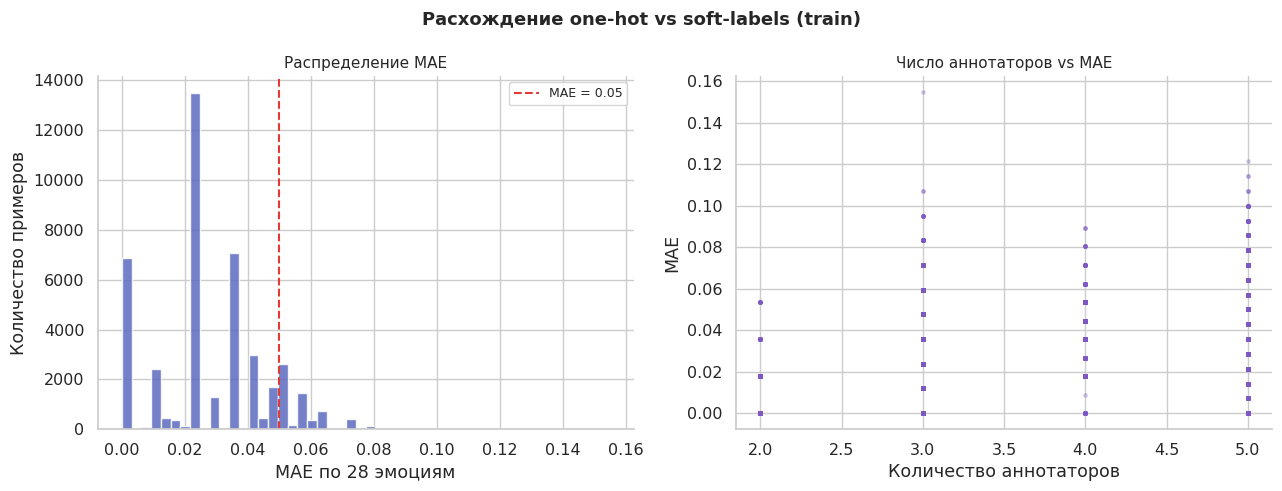

data/soft_vs_onehot_divergence.png


In [18]:
# График 1: распределение MAE + scatter число аннотаторов vs MAE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Расхождение one-hot vs soft-labels (train)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.hist(df_compare["mae"], bins=50, color="#5C6BC0", edgecolor="white", alpha=0.85)
ax.axvline(0.05, color="#E53935", linestyle="--", linewidth=1.5, label="MAE = 0.05")
ax.set_title("Распределение MAE", fontsize=11)
ax.set_xlabel("MAE по 28 эмоциям")
ax.set_ylabel("Количество примеров")
ax.legend(fontsize=9)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax2 = axes[1]
n_raters_vals = df_train_soft.set_index("id").loc[df_compare["id"], "n_raters"].values
ax2.scatter(n_raters_vals, df_compare["mae"], alpha=0.25, s=6, c="#7E57C2")
ax2.set_title("Число аннотаторов vs MAE", fontsize=11)
ax2.set_xlabel("Количество аннотаторов")
ax2.set_ylabel("MAE")
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "soft_vs_onehot_divergence.png"), dpi=150)
plt.show()
print("data/soft_vs_onehot_divergence.png")

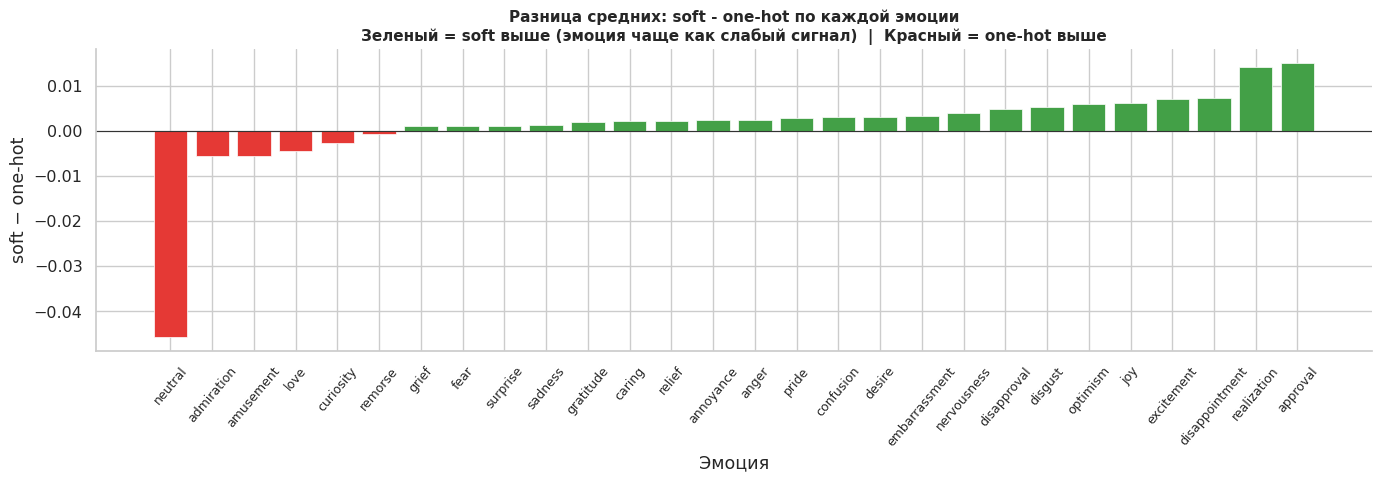

data/soft_vs_onehot_mean_diff.png


In [19]:
# График 2: разница средних soft - one-hot по каждой эмоции
mean_soft = df_train_soft[EMOTIONS].mean()
mean_onehot = df_onehot[EMOTIONS].mean()
diff = (mean_soft - mean_onehot).sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#E53935" if v < 0 else "#43A047" for v in diff.values]
ax.bar(diff.index, diff.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="#333", linewidth=0.8)
ax.set_title(
    "Разница средних: soft - one-hot по каждой эмоции\n"
    "Зеленый = soft выше (эмоция чаще как слабый сигнал)  |  "
    "Красный = one-hot выше",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Эмоция")
ax.set_ylabel("soft − one-hot")
ax.tick_params(axis="x", rotation=50, labelsize=9)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "soft_vs_onehot_mean_diff.png"), dpi=150)
plt.show()
print("data/soft_vs_onehot_mean_diff.png")

one-hot завышает neutral и сильные очевидные эмоции, soft завышает редкие вторичные эмоции. Моя гипотеза состоит в том, что модель обученная на soft-labels будет лучше распознавать именно эти редкие случаи

## Сохранение данных

In [20]:
cols_to_save = ["id", "text"] + EMOTIONS

df_train_soft[cols_to_save].to_csv(os.path.join(DATA_DIR, "train_soft.csv"), index=False)
df_val_soft[cols_to_save].to_csv(os.path.join(DATA_DIR, "val_soft.csv"), index=False)
df_test_soft[cols_to_save].to_csv(os.path.join(DATA_DIR, "test_soft.csv"), index=False)

print(f"data/train_soft.csv - {len(df_train_soft)} примеров")
print(f"data/val_soft.csv - {len(df_val_soft)} примеров")
print(f"data/test_soft.csv - {len(df_test_soft)} примеров")

data/train_soft.csv - 43410 примеров
data/val_soft.csv - 5426 примеров
data/test_soft.csv - 5427 примеров
